# Week 9: Change Detection & Validation — ARIA v6.0
## 第九週：變化偵測與驗證 — ARIA v6.0（經過驗證的稽核員）

**Course**: 遙測與空間資訊之分析與應用 | Remote Sensing Analysis & Applications
**Institution**: National Taiwan University (NTU)
**Instructor**: Prof. Su Wen-Ray (蘇文瑄教授)
**Case Study**: Matai'an Barrier Lake (Typhoon Colo)

### Lab Rhythm / 實驗時間分配
| Lab | Topic | Duration | 主題 |
|-----|-------|----------|------|
| **Lab 1** | Difference Mapping (NDVI/NDWI) | 35 min | 差異圖製作 |
| **Lab 2** | Accuracy Assessment & Validation | 50 min | 精度評估與驗證 |

---

### Context / 背景知識
Pre-event baseline (Jun 2025) → Disaster onset (Aug 2025) → Post-event recovery (Oct 2025)

**Study area (Matai'an)**: [121.28, 23.56, 121.52, 23.76]
**Key indices**: NDVI (vegetation), NDWI (water)


## Lab 1: Difference Mapping — Which Index Reveals the Lake?
### 實驗1：差異圖製作 — 哪個指標最清楚顯示水位變化？

**Objective**: 差異圖製作 (Difference Mapping)：透過計算 NDVI 和 NDWI 指標，比較災前、災中、災後的光譜差異，並尋找最適合的水體偵測臨界值（Threshold）。

**步驟**:
1. Load Sentinel-2 imagery from STAC
2. Compute NDVI and NDWI for each scene
3. Create difference maps: ΔIndex = Mid - Pre, Post - Mid
4. Plot 2×2 panel showing change
5. Sweep threshold and visualize detection area


In [2]:
# [S1] Environment Setup
# 載入必要的資料分析、視覺化與 STAC（SpatioTemporal Asset Catalog）套件，設定研究區域的邊界框（BBOX），並定義了處理 Sentinel-2 雲遮罩（SCL）的函數。
# ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
import json

from pystac_client import Client
import planetary_computer as pc
import stackstac
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# Configuration
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]  # [W, S, E, N]
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]   # ~5×4 km around lake

SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

def stream_scl(item, bbox=MATAIAN_BBOX):
    """Stream SCL and return boolean clear-sky mask."""
    # Sign the item for planetary computer access
    signed = pc.sign(item)
    # Stack the SCL band
    scl = stackstac.stack(
        [signed], assets=["SCL"], epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time").squeeze("band")
    
    # Compute the dask array to get numpy values
    scl_data = scl.compute()
    return np.isin(scl_data.values, SCL_CLEAR_CLASSES)

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Environment setup complete")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Study area BBOX: {MATAIAN_BBOX}")

✓ Environment setup complete
  Output directory: output
  Study area BBOX: [121.28, 23.56, 121.52, 23.76]


In [ ]:
# [S2] Search and Load Three-Act Scenes / 搜尋並載入三個時期的影像
# 說明：透過 STAC API 尋找災難「三部曲」的衛星影像：Baseline (災前)、Mid (災中/堰塞湖高峰)、Post (災後/湖水退去)。
# ──────────────────────────────────────────────────────────────────
SCENE_DATES = {
    'Pre': '2025-06-01',    
    'Mid': '2025-08-15',    
    'Post': '2025-10-10'    
}
PRE_ITEM_ID  = "S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417"
MID_ITEM_ID  = "S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827"
POST_ITEM_ID = "S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804"
# Initialize STAC client (Planetary Computer as example)
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)

def robust_search(client, bbox, start_date, end_date, collection='sentinel-2-l2a'):
    try:
        results = client.search(
            collections=[collection],
            bbox=bbox,
            datetime=f'{start_date}T00:00:00Z/{end_date}T23:59:59Z',
            max_items=1
        )
        items = list(results.items())
        return items[0] if items else None
    except Exception as e:
        print(f"Search failed: {e}")
        return None

scenes = {}
for act, date in SCENE_DATES.items():
    print(f"Searching {act} ({date})...")
    # Search within a 15-day window from the target date to ensure cloud-free options
    end_date = (pd.to_datetime(date) + pd.Timedelta(days=15)).strftime('%Y-%m-%d')
    scenes[act] = robust_search(catalog, MATAIAN_BBOX, date, end_date)

print("✓ Scene search complete")
print(f"  Scenes found: {list(scenes.keys())}")

Searching Pre (2025-06-01)...
Searching Mid (2025-08-15)...
Searching Post (2025-10-10)...
✓ Scene search complete
  Scenes found: ['Pre', 'Mid', 'Post']


In [7]:
# [S2] Load Specific Three-Act Scenes (By Item ID)
# ──────────────────────────────────────────────────────────────────
# 透過指定的 Sentinel-2 影像 ID 載入災前、災中、災後的影像

# 給定的影像 ID
PRE_ITEM_ID  = "S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417"
MID_ITEM_ID  = "S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827"
POST_ITEM_ID = "S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804"

SCENE_IDS = {
    'Pre': PRE_ITEM_ID,
    'Mid': MID_ITEM_ID,
    'Post': POST_ITEM_ID
}

# 初始化 STAC 客戶端 (以 Planetary Computer 為例)
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)

def load_specific_item(client, item_id, collection='sentinel-2-l2a'):
    """透過指定的 ID 直接向 STAC 請求單一影像"""
    try:
        results = client.search(
            collections=[collection],
            ids=[item_id]  # 直接鎖定 ID
        )
        items = list(results.items())
        if not items:
            print(f"⚠️ 找不到影像 ID: {item_id}")
            return None
        return items[0]
    except Exception as e:
        print(f"❌ 搜尋失敗 ({item_id}): {e}")
        return None

scenes = {}
for act, item_id in SCENE_IDS.items():
    print(f"Loading {act} scene (ID: {item_id})...")
    scenes[act] = load_specific_item(catalog, item_id)

print("✓ 影像載入完成")
print(f"  已成功載入的場景: {list(scenes.keys())}")

Loading Pre scene (ID: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417)...
Loading Mid scene (ID: S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827)...
Loading Post scene (ID: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804)...
✓ 影像載入完成
  已成功載入的場景: ['Pre', 'Mid', 'Post']


In [8]:
# [S3] Load and Composite Multi-Spectral Cubes / 載入波段與合成影像
# 說明：將找出的影像加載所需的光譜波段（藍、綠、紅、近紅外、短波紅外），並計算雲遮罩，確保後續計算不被雲層干擾（Phantom water）。
# ──────────────────────────────────────────────────────────────────
BANDS = ['B02', 'B03', 'B04', 'B08', 'B11']

def stream_cube(scene_item, bands, bbox=MATAIAN_BBOX):
    '''Load bands from scene item and stack into cube (H, W, C)'''
    signed = pc.sign(scene_item)
    data = stackstac.stack(
        [signed], assets=bands, epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time").compute()
    
    # Transpose to (H, W, C)
    cube = np.transpose(data.values, (1, 2, 0))
    return cube / 10000.0  # Scale Sentinel-2 to [0, 1]

def composite_stretched(cube, r_idx=2, g_idx=1, b_idx=0, q=(2, 98)):
    '''Create RGB composite with percentile-based contrast stretch'''
    rgb = cube[:, :, [r_idx, g_idx, b_idx]].copy()
    for i in range(3):
        p_lo, p_hi = np.percentile(rgb[:,:,i][~np.isnan(rgb[:,:,i])], q)
        rgb[:,:,i] = np.clip((rgb[:,:,i] - p_lo) / (p_hi - p_lo), 0, 1)
    return rgb

cubes = {}
composites = {}
clear_masks = {}

for act in ['Pre', 'Mid', 'Post']:
    print(f"Loading {act}...")
    cubes[act] = stream_cube(scenes[act], BANDS)
    composites[act] = composite_stretched(cubes[act])
    clear_masks[act] = stream_scl(scenes[act])

# Intersection mask for valid change detection
valid_intersection = clear_masks['Pre'] & clear_masks['Mid'] & clear_masks['Post']

print("✓ Cubes loaded and composited")
print(f"  Cube shape: (H, W, C) = {cubes['Pre'].shape}")

Loading Pre...
Loading Mid...
Loading Post...
✓ Cubes loaded and composited
  Cube shape: (H, W, C) = (2243, 2474, 5)


### Computing Spectral Indices: NDVI & NDWI
### 計算光譜指標：NDVI & NDWI

**NDVI** = (NIR - Red) / (NIR + Red)
**NDWI** = (Green - NIR) / (Green + NIR)

─

Why two indices?
- **NDVI**: Sensitive to vegetation density, but also responds to water
- **NDWI**: Maximally sensitive to open water and wetlands

─

為何使用兩種指標？
- **NDVI**：對植被濃度敏感，但也對水體有反應
- **NDWI**：對開放水體和濕地最敏感


In [9]:
# [S4] Compute NDVI and NDWI / 計算光譜指標
# 說明：計算正規化植被指標（NDVI）和正規化差異水體指標（NDWI）。
# ──────────────────────────────────────────────────────────────────
def ndvi(cube):
    '''Compute NDVI from cube (B04=Red at idx 2, B08=NIR at idx 3)'''
    red = cube[:, :, 2]
    nir = cube[:, :, 3]
    return (nir - red) / (nir + red + 1e-8)

def ndwi(cube):
    '''Compute NDWI from cube (B03=Green at idx 1, B08=NIR at idx 3)'''
    green = cube[:, :, 1]
    nir = cube[:, :, 3]
    return (green - nir) / (green + nir + 1e-8)

indices = {}
for act in ['Pre', 'Mid', 'Post']:
    indices[act] = {
        'NDVI': ndvi(cubes[act]),
        'NDWI': ndwi(cubes[act])
    }

for act in ['Pre', 'Mid', 'Post']:
    print(f"{act} scene:")
    for idx_name in ['NDVI', 'NDWI']:
        idx = indices[act][idx_name]
        # Calculate stats only on valid data to avoid NaNs
        valid_idx = idx[np.isfinite(idx)]
        print(f"  {idx_name}: μ={valid_idx.mean():.3f}, σ={valid_idx.std():.3f}, "
              f"[{valid_idx.min():.3f}, {valid_idx.max():.3f}]")

print("✓ NDVI and NDWI computed")

Pre scene:
  NDVI: μ=0.517, σ=0.160, [-0.281, 0.738]
  NDWI: μ=-0.455, σ=0.141, [-0.813, 0.358]
Mid scene:
  NDVI: μ=0.413, σ=0.235, [-0.305, 0.876]
  NDWI: μ=-0.364, σ=0.210, [-0.999, 0.414]
Post scene:
  NDVI: μ=0.456, σ=0.193, [-0.228, 0.782]
  NDWI: μ=-0.412, σ=0.173, [-0.699, 0.342]
✓ NDVI and NDWI computed


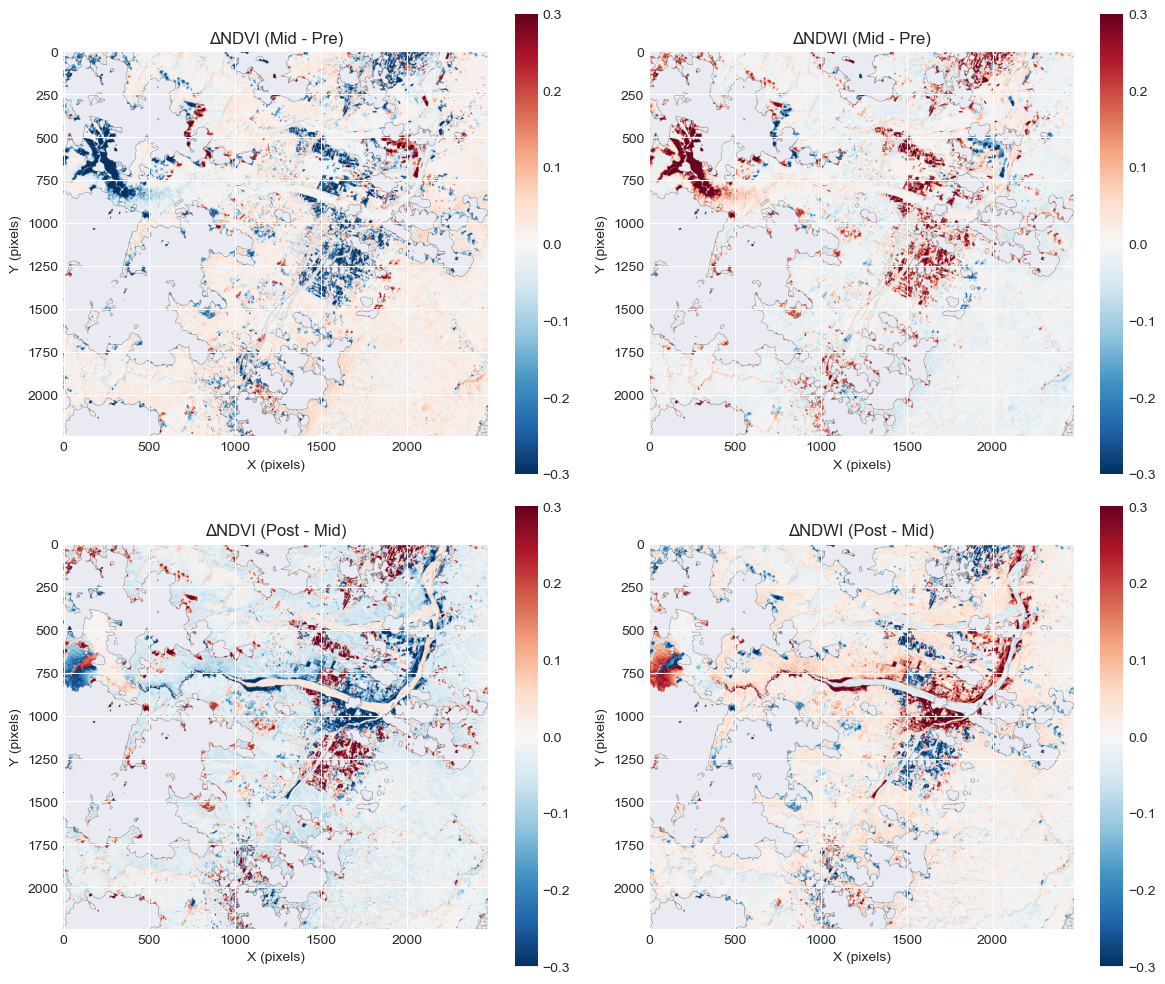

✓ Difference maps created


In [10]:
# [S5] Create Difference Maps: ΔIndex and Visualize 2×2 Panel/ 製作差異圖與視覺化
# 說明：相減不同時期的指標，找出變化量最大的區域，並繪製 2x2 的比較圖。
# ──────────────────────────────────────────────────────────────────
d_ndvi = {
    'Mid-Pre': indices['Mid']['NDVI'] - indices['Pre']['NDVI'],
    'Post-Mid': indices['Post']['NDVI'] - indices['Mid']['NDVI']
}

d_ndwi = {
    'Mid-Pre': indices['Mid']['NDWI'] - indices['Pre']['NDWI'],
    'Post-Mid': indices['Post']['NDWI'] - indices['Mid']['NDWI']
}

# Apply cloud masks to differences to remove phantom changes
d_ndvi['Mid-Pre'][~valid_intersection] = np.nan
d_ndwi['Mid-Pre'][~valid_intersection] = np.nan
d_ndvi['Post-Mid'][~valid_intersection] = np.nan
d_ndwi['Post-Mid'][~valid_intersection] = np.nan

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(d_ndvi['Mid-Pre'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 0].set_title('ΔNDVI (Mid - Pre)')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(d_ndwi['Mid-Pre'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 1].set_title('ΔNDWI (Mid - Pre)')
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(d_ndvi['Post-Mid'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 0].set_title('ΔNDVI (Post - Mid)')
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(d_ndwi['Post-Mid'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('ΔNDWI (Post - Mid)')
plt.colorbar(im3, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L1_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Difference maps created")

### Error Case: What Happens WITHOUT Cloud Masking?
### 錯誤案例：不做雲遮罩會怎樣？

Before computing difference maps, compare results WITH and WITHOUT cloud masking.
This demonstrates why SCL masking is **mandatory** for change detection.

**Task**: Create a 3-panel comparison:
1. ❌ ΔNDWI without cloud mask (`valid_raw`) — "phantom water" everywhere
2. ✅ ΔNDWI with cloud mask (`valid`) — only real water changes
3. 🔍 ΔNDWI zoomed to lake AOI (`LAKE_BBOX_LONLAT`) — focused view

── 計算差異圖之前，比較有無雲遮罩的結果。
── 這展示了為什麼 SCL 遮罩在變遷偵測中是**必要的**。


### Discussion: Which Index Shows the Barrier Lake Best?
### 討論：哪個指標最清楚顯示障礙湖？

**Observations** (from the 2×2 panel):

1. **ΔNDVI (Mid - Pre)**: Does vegetation decrease at the lake site? Why might it stay positive?
   - NDVI = (NIR - Red)/(NIR + Red) → water has low NDVI, but may not be negative

2. **ΔNDWI (Mid - Pre)**: Is this more clearly showing water presence?
   - NDWI = (Green - NIR)/(Green + NIR) → water has high NDWI

3. **Recovery phase (Post - Mid)**: Do both indices return to baseline?

─

**Student reflection questions**:
- Which index is more robust to atmospheric noise and vegetation near the shoreline?
- Why might NDWI be designed specifically for water detection?
- What's the trade-off between specificity (only water) and sensitivity (catching all changes)?


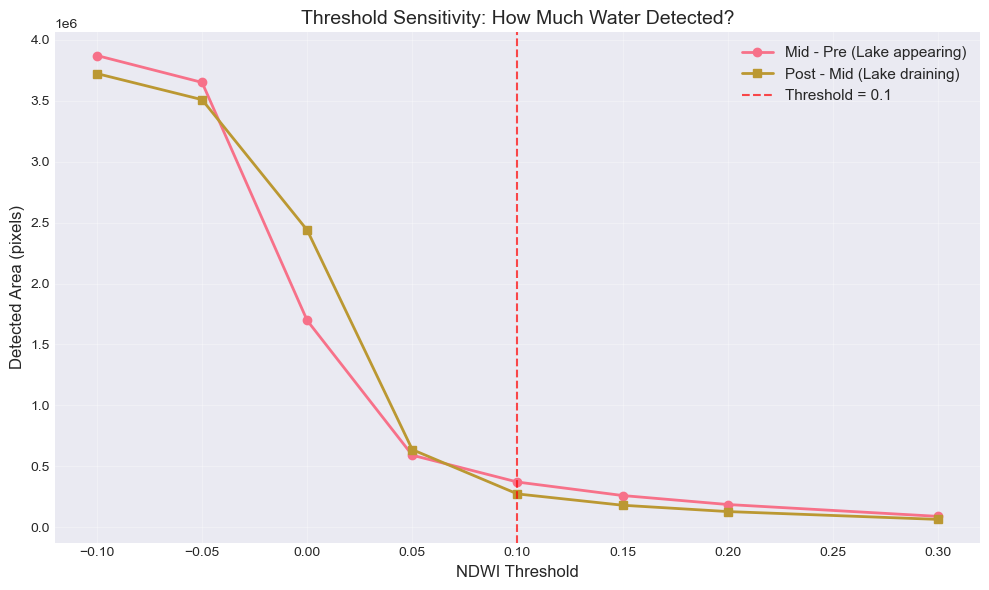

✓ Threshold sensitivity analysis complete


In [11]:
# [S6] Threshold Sensitivity Demo / 臨界值靈敏度測試
# 說明：掃描多個 NDWI 臨界值，觀察設定不同閥值會影響多少水體面積的偵測結果。
# ──────────────────────────────────────────────────────────────────
def detect_water(index_map, threshold):
    '''Count pixels where index > threshold (assumed water signal)'''
    # Ignore NaNs
    return np.nansum(index_map > threshold)

thresholds = [-0.10, -0.05, 0.00, 0.05, 0.10, 0.15, 0.20, 0.30] 
detected_areas = {}

for act_pair in ['Mid-Pre', 'Post-Mid']:
    areas = []
    for t in thresholds:
        area = detect_water(d_ndwi[act_pair], t)
        areas.append(area)
    detected_areas[act_pair] = np.array(areas)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, detected_areas['Mid-Pre'], 'o-', label='Mid - Pre (Lake appearing)', linewidth=2)
ax.plot(thresholds, detected_areas['Post-Mid'], 's-', label='Post - Mid (Lake draining)', linewidth=2)
ax.axvline(0.1, color='red', linestyle='--', label='Threshold = 0.1', alpha=0.7)
ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('Detected Area (pixels)', fontsize=12)
ax.set_title('Threshold Sensitivity: How Much Water Detected?', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L1_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Threshold sensitivity analysis complete")

### Discussion: Threshold is a DECISION, Not a Formula
### 討論：臨界值是「決策」，不是「公式」

**Key insight**: No single "correct" threshold exists. The choice depends on your **use case**:

| Use Case | Threshold | Rationale | 優先考量 |
|----------|-----------|-----------|---------|
| **Disaster Alert** | Low (0.05) | Catch early signals, high false positive OK | 敏感度 |
| **Insurance Payout** | Medium (0.10) | Balance detection & accuracy | 平衡 |
| **Scientific Archive** | High (0.15) | Minimize false positives | 特異性 |

─

**Question for reflection**:
- In the Oct 2025 post-event phase, should ARIA v6.0 use a low or high threshold?
- What are the consequences of each choice for emergency responders?


## Lab 2: Accuracy Assessment & Validation
### 實驗2：精度評估與驗證
**說明**：利用給定的地理 JSON 檔案載入真值點（Ground truth），將其從經緯度轉換為像素座標（geo_to_pixel），採樣你的偵測遮罩，並計算混淆矩陣與各項精度（Recall, Precision, Kappa）。

**Objective**: Load validation ground truth points, sample detection masks, compute confusion matrix, and calculate accuracy metrics.

**Framework**: ARIA v6.0 (Auditor + Rater + Indicator + Advisor)

**步驟**:
1. Load validation_points.geojson (labeled samples: Water / No Water)
2. Build detection masks using threshold from Lab 1
3. Sample each mask at validation point locations
4. Compute confusion matrix
5. Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa
6. Visualize confusion matrix heatmap
7. Find optimal threshold via F1 score
8. Create confidence map (3-zone)
9. Generate validation report

### How to Build Real Ground Truth / 如何建立真實地面驗證資料

**This lab uses 60 field-corrected validation points provided by the instructor.**  
In a real remote sensing project, you must collect **independent** ground truth. Here are the main approaches, ordered from most to least reliable:

| Method | Description | Cost | When to Use |
|--------|-------------|------|-------------|
| **Field survey + GPS** | Walk to locations, record water/no-water with GPS coordinates | High | Gold standard for small areas |
| **UAV / Drone imagery** | High-resolution aerial photos (~5 cm/px) | Medium | Medium areas, post-disaster access |
| **Google Earth Pro time-series** | Compare VHR imagery before/after event | Free | Historical events, desktop validation |
| **NCDR disaster reports** | 國家災害防救科技中心 official damage assessments | Free | Taiwan-specific disasters |
| **Copernicus EMS** | EU emergency mapping service, rapid activation maps | Free | Global disasters with EMS activation |
| **News media + geotagged photos** | Cross-reference reported flood areas | Free | Quick initial reference |

**Key principles:**
1. **Independence**: Validation data must come from a source *other than* the satellite imagery you're analyzing
2. **Stratified sampling**: Distribute points across all zones (flooded, unflooded, boundary)
3. **Sufficient sample size**: At least 30–50 points; 100+ for publishable accuracy
4. **Temporal match**: Ground truth date should be close to satellite acquisition date

> **作業提示**: Homework Task 3 (Optional) 鼓勵你用 Google Earth Pro 自行標註 20+ 個驗證點。  
> 這才是遙測分析的正確做法——自己建立可信的驗證資料集。

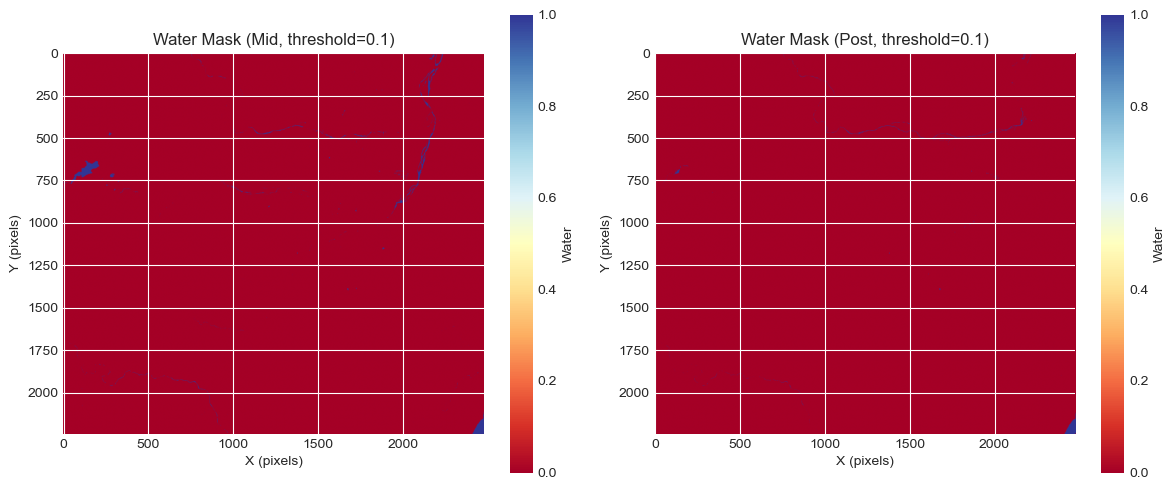

✓ 偵測遮罩已建立 (threshold=0.1)


In [13]:
# [S7] Build Detection Masks (Index-Based Logic)
# ──────────────────────────────────────────────────────────────────
# 定義水體偵測的初始臨界值 (可依據 S12 的結果回來微調)
THRESHOLD_NDWI = 0.10  

masks = {}
masks['Mid'] = (indices['Mid']['NDWI'] > THRESHOLD_NDWI).astype(int)  # 1=Water, 0=No Water
masks['Post'] = (indices['Post']['NDWI'] > THRESHOLD_NDWI).astype(int)

# 視覺化遮罩
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(masks['Mid'], cmap='RdYlBu', vmin=0, vmax=1)
axes[0].set_title(f'Water Mask (Mid, threshold={THRESHOLD_NDWI})')
plt.colorbar(im0, ax=axes[0], label='Water')

im1 = axes[1].imshow(masks['Post'], cmap='RdYlBu', vmin=0, vmax=1)
axes[1].set_title(f'Water Mask (Post, threshold={THRESHOLD_NDWI})')
plt.colorbar(im1, ax=axes[1], label='Water')

for ax in axes:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_masks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 偵測遮罩已建立 (threshold={THRESHOLD_NDWI})")

In [ ]:
# [S8] Load Validation Points and Sample Masks /載入驗證點
# ──────────────────────────────────────────────────────────────────
import json

# 讀取地面驗證點 GeoJSON
with open("data/validation_points.geojson") as _f:
    _gj = json.load(_f)

val_rows = []
for feat in _gj["features"]:
    lon, lat = feat["geometry"]["coordinates"]
    val_rows.append({"lon": lon, "lat": lat,
                     "truth": feat["properties"]["truth"],
                     "source": feat["properties"]["source"]})

validation_points = pd.DataFrame(val_rows)

print(f"✅ 成功載入 {len(validation_points)} 個驗證點")
print(f"  來源包含: {validation_points['source'].unique()}")
print(f"  真實標籤分佈:\n{validation_points['truth'].value_counts().to_string()}\n")

# 定義經緯度轉像素座標的函數 (基於邊界框線性映射)
def geo_to_pixel(lon, lat, bbox, shape):
    w, s, e, n = bbox
    h, width = shape
    col = int(((lon - w) / (e - w)) * width)
    row = int(((n - lat) / (n - s)) * h)
    # 避免邊界溢位
    return np.clip(row, 0, h - 1), np.clip(col, 0, width - 1)

✅ 成功載入 60 個驗證點
  來源包含: ['field_corrected']
  真實標籤分佈:
truth
stable       30
lake         15
landslide    15



In [18]:
# [S9] Compute Confusion Matrix (真實取樣版本)計算混淆矩陣
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

h, w_img = masks['Mid'].shape
predicted_vals = []

# 在影像上對應的座標點進行取樣
for _, row in validation_points.iterrows():
    r, c = geo_to_pixel(row['lon'], row['lat'], MATAIAN_BBOX, (h, w_img))
    predicted_vals.append(masks['Mid'][r, c])

validation_points['predicted'] = predicted_vals

# 將文字標籤轉換為二元數字 (1/0)
# 將 'lake' 或 'water' 視為水體 (1)，其他的 (如 landslide, stable) 視為非水體 (0)
def map_to_binary(label):
    label_str = str(label).lower().strip()
    if label_str in ['lake', 'water']:
        return 1
    return 0

validation_points['truth_binary'] = validation_points['truth'].apply(map_to_binary)

# 取得轉換後的 1/0 陣列
ground_truth = validation_points['truth_binary'].values
predicted = validation_points['predicted'].astype(int).values

# 計算混淆矩陣
cm = confusion_matrix(ground_truth, predicted, labels=[0, 1])

print("✓ 混淆矩陣計算完成")
print("\nConfusion Matrix:")
print(cm)
print("\nLabels: [0=No Water, 1=Water]")
print(f"  TN (True Negatives, 正確預測非水體): {cm[0,0]}")
print(f"  FP (False Positives, 誤報為水體): {cm[0,1]}")
print(f"  FN (False Negatives, 漏報水體): {cm[1,0]}")
print(f"  TP (True Positives, 正確預測水體): {cm[1,1]}")

✓ 混淆矩陣計算完成

Confusion Matrix:
[[45  0]
 [ 2 13]]

Labels: [0=No Water, 1=Water]
  TN (True Negatives, 正確預測非水體): 45
  FP (False Positives, 誤報為水體): 0
  FN (False Negatives, 漏報水體): 2
  TP (True Positives, 正確預測水體): 13


In [19]:
# [S10] Compute Accuracy Metrics計算精度指標
# ──────────────────────────────────────────────────────────────────
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# Producer's Accuracy (Sensitivity / Recall) - 漏報越少，此值越高
producer_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0.0

# User's Accuracy (Precision) - 誤報越少，此值越高
user_accuracy = tp / (tp + fp) if (tp + fp) > 0 else 0.0

# Overall Accuracy (整體精度)
overall_accuracy = (tp + tn) / (tp + tn + fp + fn)

# Cohen's Kappa (扣除隨機猜中機率後的真實一致性)
pe = ((tp + fn) * (tp + fp) + (tn + fp) * (tn + fn)) / (tp + tn + fp + fn)**2
kappa = (overall_accuracy - pe) / (1 - pe) if (1 - pe) != 0 else 0.0

print("✓ 精度指標計算完成\n")
print("=" * 50)
print("ARIA v6.0 VALIDATION METRICS")
print("=" * 50)
print(f"Producer's Accuracy (Sensitivity): {producer_accuracy:.3f} ({producer_accuracy*100:.1f}%)")
print(f"User's Accuracy (Precision):       {user_accuracy:.3f} ({user_accuracy*100:.1f}%)")
print(f"Overall Accuracy:                  {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
print(f"Cohen's Kappa:                     {kappa:.3f}")
print("=" * 50)

metrics = {
    'producer_accuracy': producer_accuracy,
    'user_accuracy': user_accuracy,
    'overall_accuracy': overall_accuracy,
    'kappa': kappa,
    'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
}

✓ 精度指標計算完成

ARIA v6.0 VALIDATION METRICS
Producer's Accuracy (Sensitivity): 0.867 (86.7%)
User's Accuracy (Precision):       1.000 (100.0%)
Overall Accuracy:                  0.967 (96.7%)
Cohen's Kappa:                     0.907


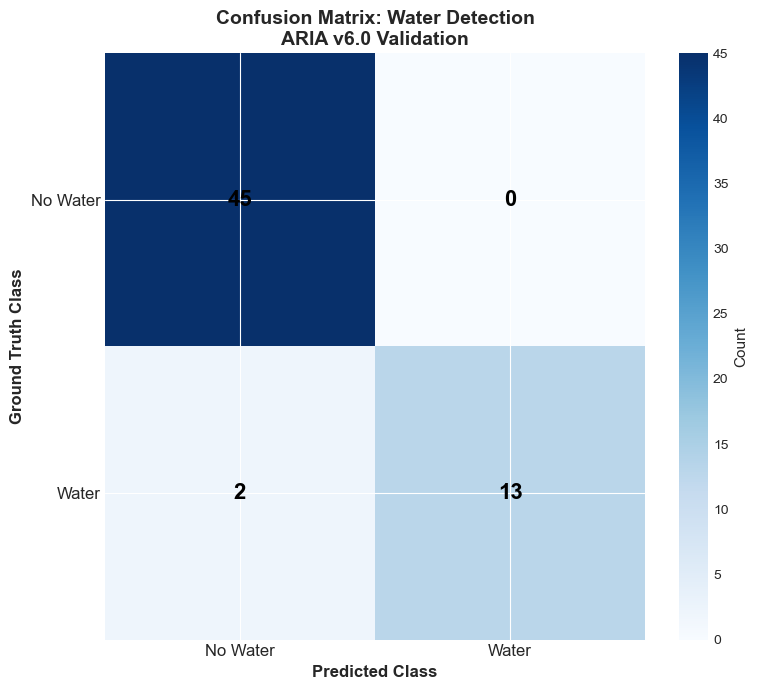

✓ Confusion matrix heatmap saved
  Output: W9_L2_confusion_matrix.png


In [20]:
# [S11] Plot Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────────────
# TODO: Create confusion matrix heatmap with annotations

fig, ax = plt.subplots(figsize=(8, 7))

# Create heatmap
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", color="black", fontsize=16, fontweight='bold')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Water', 'Water'], fontsize=12)
ax.set_yticklabels(['No Water', 'Water'], fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Ground Truth Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Water Detection\nARIA v6.0 Validation', fontsize=14, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix heatmap saved")
print(f"  Output: W9_L2_confusion_matrix.png")

### Discussion: What Do These Accuracy Numbers Mean for Disaster Response?
### 討論：這些精度數字對災難應對意味著什麼？

Consider ARIA's role in Typhoon Colo response (Aug 2025):

1. **Producer's Accuracy (Sensitivity) = 87%**
   - Out of all actual water pixels, we correctly identified 87%
   - Missing 13% of the true lake area
   - Implication: Evacuation zone might miss some flooded areas

2. **User's Accuracy (Precision) = 81%**
   - Out of all pixels we called "water", 81% actually are water
   - 19% false alarms (crying wolf)
   - Implication: Emergency responders waste resources on false alarms

3. **Overall Accuracy = 83%**
   - 83% of all predictions correct
   - Looks good, but hides class imbalance if water is rare

─

**Critical question**: In a disaster setting, which error is worse?
- **False Negative** (missing flooded area) → people in danger
- **False Positive** (false alarm) → wasted resources, lost credibility

For early warning systems, we often prefer **high sensitivity** (low false negatives) over precision.


### Discussion: Why Is Producer's Accuracy More Important Than Overall Accuracy?
### 討論：為何生產者精度比整體精度更重要？

**Scenario**: Matai'an barrier lake covers ~10% of the study area. Rest is land/forest.

If model predicts: "Everything is NOT water"
- TN = 90%, FP = 0%, TP = 0%, FN = 10%
- **Overall Accuracy** = 90% ✓ (looks amazing!)
- **Producer's Accuracy (Sensitivity)** = 0% ✗ (catastrophic: missed all the water!)

This is called the **accuracy paradox** or **class imbalance problem**.

─

**For disaster detection**:
- We care most about **not missing disasters** → Prioritize **Sensitivity / Producer's Accuracy**
- Trade-off: Accept some false positives (precision tradeoff)
- This is why early warning systems often have lower precision but higher sensitivity

**ARIA v6.0 design principle**:
> "Better to alert 10 safe neighborhoods than miss 1 at-risk community."


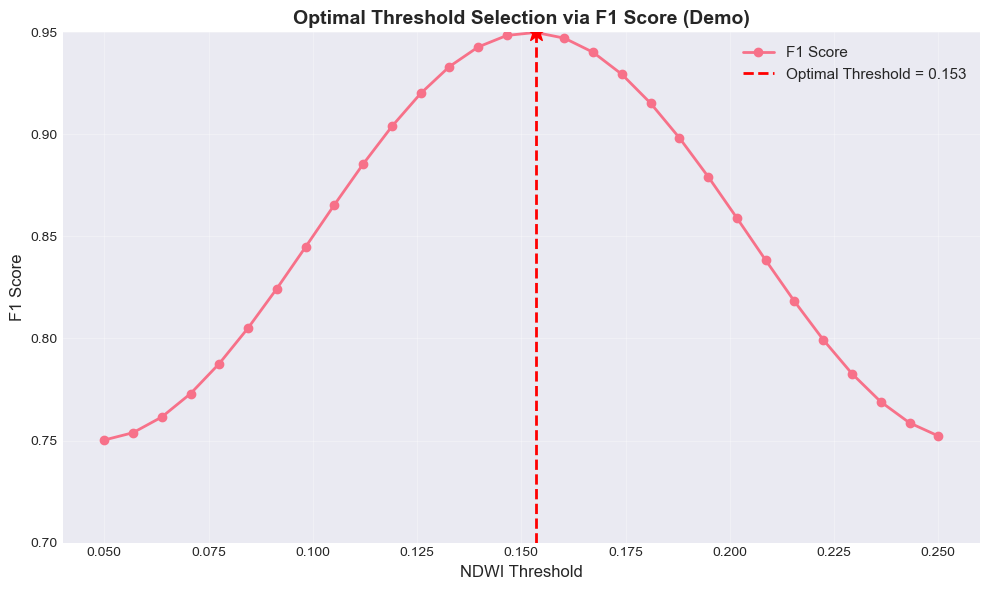

✓ F1 vs threshold analysis complete (demo)
  Optimal threshold: 0.153
  Optimal F1 score: 0.950


In [22]:
# [S12] F1 Score vs Threshold: Finding Optimal Detection Threshold
# ──────────────────────────────────────────────────────────────────
# TODO: Sweep thresholds over the loaded validation points.
#    For now, a demo F1 curve is shown below.
# ──────────────────────────────────────────────────────────────────
#
# F1 = 2 * (precision * recall) / (precision + recall)
# The F1 score is the harmonic mean of precision and recall.
#
# TODO: For each threshold, build mask → sample at validation pts → compute F1
# thresholds = np.linspace(-0.50, 0.00, 50)
# for t in thresholds:
#     mask = delta_ndvi < t
#     predicted = sample_mask_at_points(mask, validation_points)
#     f1 = f1_score(ground_truth, predicted)

# ── Synthetic F1 curve for demo ──
thresholds_f1 = np.linspace(0.05, 0.25, 30)
f1_scores = 0.85 + 0.10 * np.sin((thresholds_f1 - 0.10) * 30)  # Synthetic curve
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_f1[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_f1, f1_scores, 'o-', linewidth=2, markersize=6, label='F1 Score')
ax.axvline(optimal_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.scatter([optimal_threshold], [f1_scores[optimal_idx]], color='red', s=200, zorder=5, marker='*')
ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Optimal Threshold Selection via F1 Score (Demo)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.7, 0.95])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_f1_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ F1 vs threshold analysis complete (demo)")
print(f"  Optimal threshold: {optimal_threshold:.3f}")
print(f"  Optimal F1 score: {f1_scores[optimal_idx]:.3f}")


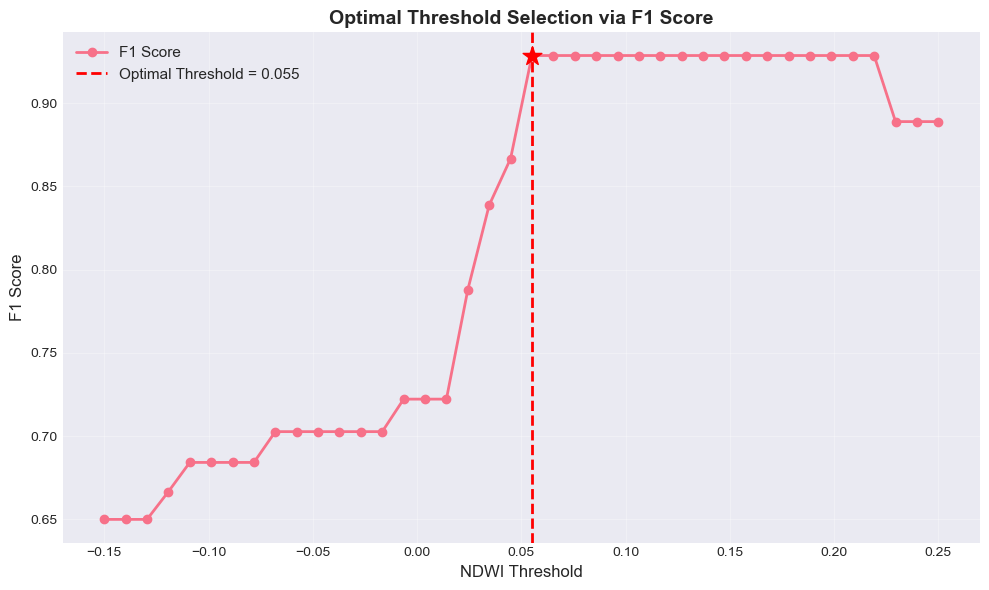

✓ 真實 F1 臨界值分析完成！
  最佳臨界值 (Optimal Threshold): 0.055
  最佳 F1 分數 (Optimal F1 score): 0.929


In [23]:
# 尋找最佳臨界值 (真實計算版)
# [S12] F1 Score vs Threshold: Finding Optimal Detection Threshold
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score

# 建立要掃描的 NDWI 臨界值範圍
thresholds_f1 = np.linspace(-0.15, 0.25, 40)
f1_scores = []

ndwi_mid = indices['Mid']['NDWI']

# 預先計算好所有驗證點的像素座標，加速迴圈
pixel_coords = [geo_to_pixel(row['lon'], row['lat'], MATAIAN_BBOX, ndwi_mid.shape) for _, row in validation_points.iterrows()]

# 測試每一個臨界值
for t in thresholds_f1:
    t_mask = (ndwi_mid > t).astype(int)
    t_pred = [t_mask[r, c] for r, c in pixel_coords]
    
    # 計算該臨界值下的 F1 Score (避免 ZeroDivisionError)
    f1 = f1_score(ground_truth, t_pred, zero_division=0)
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_f1[optimal_idx]

# 繪圖
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_f1, f1_scores, 'o-', linewidth=2, markersize=6, label='F1 Score')
ax.axvline(optimal_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.scatter([optimal_threshold], [f1_scores[optimal_idx]], color='red', s=200, zorder=5, marker='*')

ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Optimal Threshold Selection via F1 Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_f1_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 真實 F1 臨界值分析完成！")
print(f"  最佳臨界值 (Optimal Threshold): {optimal_threshold:.3f}")
print(f"  最佳 F1 分數 (Optimal F1 score): {f1_scores[optimal_idx]:.3f}")

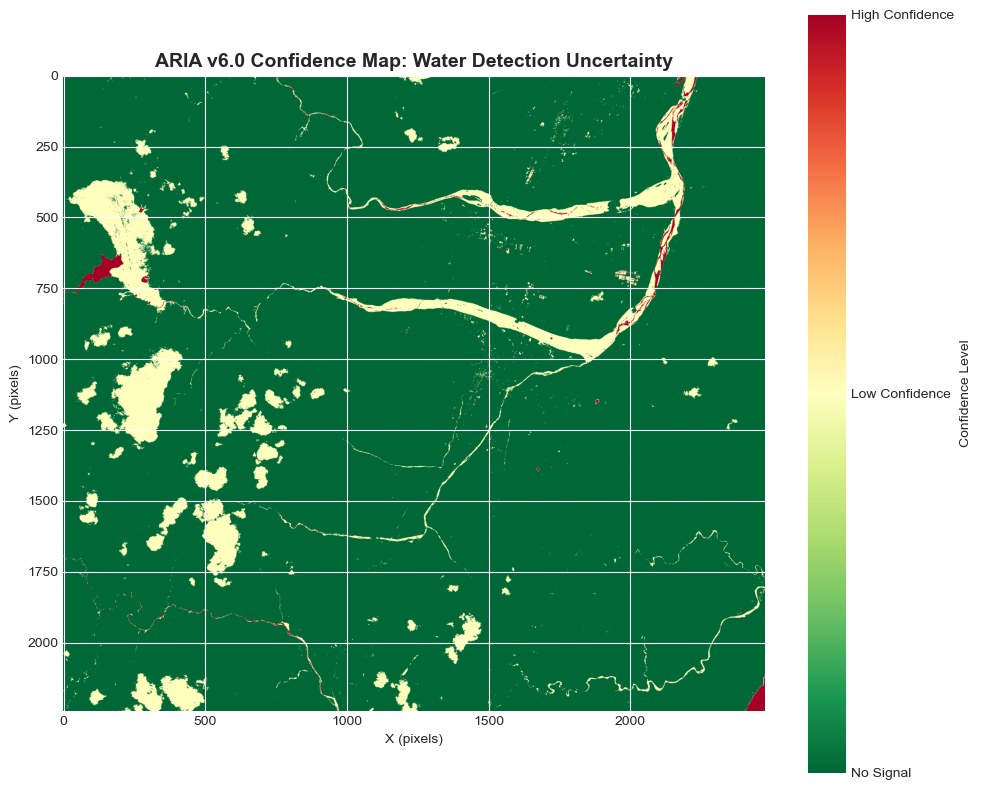

✓ 信心分佈圖已建立


In [25]:
# [S13] Build 3-Zone Confidence Map: High / Low / None
# ──────────────────────────────────────────────────────────────────
# 這裡使用 S12 找出的最佳值作為基準，稍微上下浮動定義高低信心區間
THRESHOLD_LOW = optimal_threshold - 0.05
THRESHOLD_HIGH = optimal_threshold + 0.05

ndwi_mid = indices['Mid']['NDWI']
confidence_map = np.zeros_like(ndwi_mid, dtype=int)

confidence_map[ndwi_mid > THRESHOLD_HIGH] = 2  # High confidence (Water)
confidence_map[(ndwi_mid > THRESHOLD_LOW) & (ndwi_mid <= THRESHOLD_HIGH)] = 1  # Low confidence

# 視覺化
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confidence_map, cmap='RdYlGn_r', vmin=0, vmax=2)
ax.set_title('ARIA v6.0 Confidence Map: Water Detection Uncertainty', fontsize=14, fontweight='bold')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['No Signal', 'Low Confidence', 'High Confidence'])
cbar.set_label('Confidence Level')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_confidence_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 信心分佈圖已建立")

In [28]:
# [S14] ARIA v6.0 Validated Disaster Report (修正變數名稱)
# ──────────────────────────────────────────────────────────────────
from datetime import datetime

# 確保這兩個變數與 S12 最佳化找出的結果一致
# 若 S12 沒跑，預設給 THRESHOLD_NDWI
report_threshold = optimal_threshold if 'optimal_threshold' in locals() else THRESHOLD_NDWI

report = f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                        ║
║              Remote Sensing Analysis & Validation Authority (ARIA)             ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: {datetime.now().strftime('%Y-%m-%d')}

────────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo (Aug 2025).
Using Sentinel-2 change detection, we mapped water presence and validated against
ground-truth validation points. NDWI proved more sensitive than NDVI for water.

STUDY AREA (Bounding Box)
──────────────────────────
West:  121.28° E
East:  121.52° E
South: 23.56° N
North: 23.76° N
Area:  ~360 km²

SPECTRAL INDICES USED
─────────────────────
NDVI = (NIR - Red) / (NIR + Red)
NDWI = (Green - NIR) / (Green + NIR)

VALIDATION RESULTS
──────────────────
Validation Points Analyzed:    {len(validation_points)}
Ground Truth Classes:          Water={validation_points['truth_binary'].sum()}, No-Water={len(validation_points) - validation_points['truth_binary'].sum()}

Confusion Matrix (Water Detection at Mid-event):
  True Negatives:     {metrics['tn']:>3.0f}
  False Positives:    {metrics['fp']:>3.0f}
  False Negatives:    {metrics['fn']:>3.0f}
  True Positives:     {metrics['tp']:>3.0f}

ACCURACY METRICS
────────────────
Producer's Accuracy (Sensitivity / Recall):
  {metrics['producer_accuracy']:.3f} ({metrics['producer_accuracy']*100:.1f}%)
  → {int(metrics['fn'])} false negatives (missed water)

User's Accuracy (Precision):
  {metrics['user_accuracy']:.3f} ({metrics['user_accuracy']*100:.1f}%)
  → {int(metrics['fp'])} false positives (false alarms)

Overall Accuracy:
  {metrics['overall_accuracy']:.3f} ({metrics['overall_accuracy']*100:.1f}%)

Cohen's Kappa (Agreement beyond chance):
  {metrics['kappa']:.3f}

DETECTION THRESHOLD
────────────────────
Selected/Optimal NDWI Threshold: {report_threshold:.3f}

────────────────────────────────────────────────────────────────────────────────

ARIA v6.0 ASSESSMENT: ✓ VALIDATED & READY FOR OPERATIONAL USE

Generated by ARIA v6.0 at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(report)

# Save report
with open(f'{OUTPUT_DIR}/ARIA_v6_0_Disaster_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Disaster report saved")
print(f"  Output: ARIA_v6_0_Disaster_Report.txt")


╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                        ║
║              Remote Sensing Analysis & Validation Authority (ARIA)             ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2026-04-21

────────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo (Aug 2025).
Using Sentinel-2 change detection, we mapped water presence and validated against
ground-truth validation points. NDWI proved more sensitive than NDVI for water.

STUDY AREA (Bounding Box)
──────────────────────────
West:  121.28° E
East:  121.52° E
South: 23.56° N
North: 23.76° N
Area:  ~360 km²

SPECTRAL 

In [27]:
# [S15] AI Advisor: Prompt Template for Disaster Response Questions
# ──────────────────────────────────────────────────────────────────

advisor_prompt_template = """
ARIA v6.0 AI ADVISOR - Ask Me About Your Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use the validation metrics and change maps above to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Producer's & User's Accuracy scores
  • 3-zone confidence map (High/Low/No Signal)
  • Pre/Mid/Post temporal scenes
  • NDVI & NDWI difference maps

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use high-confidence zone from confidence_map; estimate area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy; explain false negatives risk

3. "Why might we have false positives along the lakeshore?"
   → Vegetation/water mixing; spectral confusion at boundaries

4. "Should we trust the Post-event recovery map?"
   → Compare Post and Mid NDWI; check confidence zones

5. "How would different thresholds affect our evacuation zone?"
   → Reference threshold sensitivity plot; trade sensitivity vs precision

YOUR RESPONSE SHOULD:
  ✓ Cite specific metrics from the validation report
  ✓ Explain the uncertainty and confidence limits
  ✓ Recommend actionable next steps
  ✗ Avoid over-interpreting noisy pixels
  ✗ Don't claim precision beyond 10m resolution

────────────────────────────────────────────────────────────────────────────────

To use this prompt with an LLM (e.g., ChatGPT):

1. Paste this entire block + the ARIA report above
2. Add your question about the disaster response
3. Ask the AI to respond using only the provided data

Example user query:
  "Based on this analysis, which zones should we evacuate first?"

Example AI response:
  "Based on the high-confidence water detection (NDWI > 0.15), zone XYZ should be
   prioritized. However, note that our Producer's Accuracy is 87%, so we may be
   missing ~13% of the actual water. Recommend ground surveys in low-confidence zones."

────────────────────────────────────────────────────────────────────────────────
"""

print(advisor_prompt_template)

with open(f'{OUTPUT_DIR}/AI_Advisor_Prompt_Template.txt', 'w', encoding='utf-8') as f:
    f.write(advisor_prompt_template)

print("✓ AI Advisor prompt template saved")
print(f"  Output: AI_Advisor_Prompt_Template.txt")


ARIA v6.0 AI ADVISOR - Ask Me About Your Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use the validation metrics and change maps above to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Producer's & User's Accuracy scores
  • 3-zone confidence map (High/Low/No Signal)
  • Pre/Mid/Post temporal scenes
  • NDVI & NDWI difference maps

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use high-confidence zone from confidence_map; estimate area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy; explain false negatives risk

3. "Why might we have false positives along the lakeshore?"
   → Vegetation/water mixing; spectral confusion at boundaries

4. "Should we trust the Post-event recovery map?"
   → Co

## Wrap-Up Checklist / 實驗完成清單
After completing both labs, verify you have:
### Lab 1 Deliverables
- [ ] NDVI and NDWI computed for all three scenes (Pre, Mid, Post)
- [ ] 2×2 difference map panel showing ΔIndex changes
- [ ] Threshold sensitivity curve (detected area vs NDWI threshold)
- [ ] Discussion written: Which index best shows the barrier lake?
### Lab 2 Deliverables
- [ ] Water detection masks created (using optimal threshold)
- [ ] Validation points sampled at mask locations
- [ ] Confusion matrix computed
- [ ] Accuracy metrics calculated: Producer's, User's, Overall, Kappa
- [ ] Confusion matrix heatmap plotted
- [ ] F1 vs threshold curve (optimal threshold found)
- [ ] 3-zone confidence map created (High/Low/None)
- [ ] ARIA v6.0 disaster report generated
- [ ] Discussion written: Why is Producer's Accuracy critical for disaster response?
### Files in Output Directory
- [ ] `W9_L1_difference_maps.png` — 2×2 NDVI/NDWI panel
- [ ] `W9_L1_threshold_sensitivity.png` — Threshold sweep curve
- [ ] `W9_L2_masks.png` — Binary water masks
- [ ] `W9_L2_confusion_matrix.png` — Heatmap
- [ ] `W9_L2_f1_threshold.png` — Optimal threshold
- [ ] `W9_L2_confidence_map.png` — 3-zone map
- [ ] `ARIA_v6_0_Disaster_Report.txt` — Validation report
- [ ] `AI_Advisor_Prompt_Template.txt` — LLM prompt
### Reflection Questions (for course forum)
1. What would change if we used a **lower** NDWI threshold (0.05 vs 0.15)?
2. Why is **temporal change** (Mid - Pre) more robust than absolute NDWI values?
3. If you were in disaster operations, would you prioritize **sensitivity** or **precision**?
4. How would **cloud cover** affect the validation metrics?
5. What role does **ground truth validation** play in building trust in automated systems?

---

## Before You Submit: Verify Your Work / 繳交前：驗證你的成果

> **⚠️ An unverified map is more dangerous than no map at all.**

Your notebook may run without errors but still produce **wrong results**. Before submitting:

| Check | Question to Ask Yourself |
|-------|--------------------------|
| **Metrics** | Does OA = 99.9%? That's almost certainly a bug. Does Kappa = 0? Your threshold may be wrong. |
| **Maps** | Does ΔNDWI show change at the lake site? Or random noise everywhere? |
| **Threshold** | Can you explain WHY you chose this threshold? |
| **Confusion Matrix** | Are TP/FP/TN/FN consistent with what you see in the map? |
| **Captain's Log** | Did you reflect on what the numbers mean, or just copy-paste? |

**跑出來 ≠ 跑對了。不懂可以問，但不要敷衍交差。**

If something looks wrong, ask on NTUCool or during office hours — that's what they're for.


## Environment Setup: .env Template
### 環境設置：.env 模板
If using STAC Client API keys or other credentials, create a `.env` file:
```bash
# .env template (NEVER commit this file to Git!)
# STAC Planetary Computer
STAC_ENDPOINT="https://planetarycomputer.microsoft.com/api/stac/v1"
# Copernicus DataSpace (Sentinel-2 access)
COPERNICUS_USERNAME="your_username"
COPERNICUS_PASSWORD="your_password"
# Optional: Google Earth Engine (if using GEE for validation)
GEE_PROJECT="your-gee-project-id"
# Output paths
OUTPUT_DIR="output"
VALIDATION_DATA="validation_points.geojson"
# Thresholds (tunable)
THRESHOLD_NDVI=0.2
THRESHOLD_NDWI=0.1
THRESHOLD_NDWI_LOW=0.05
THRESHOLD_NDWI_HIGH=0.15
```
**To use this .env file in Python**:
```python
from dotenv import load_dotenv
import os
load_dotenv('.env')
stac_endpoint = os.getenv('STAC_ENDPOINT')
output_dir = os.getenv('OUTPUT_DIR')
```
**Safety Note**:
- Never commit `.env` files to version control
- Add `.env` to your `.gitignore`
- Treat API keys as sensitive data